<a href="https://colab.research.google.com/github/ezeljko1981/Quantum_Computer/blob/main/dj_isceee_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

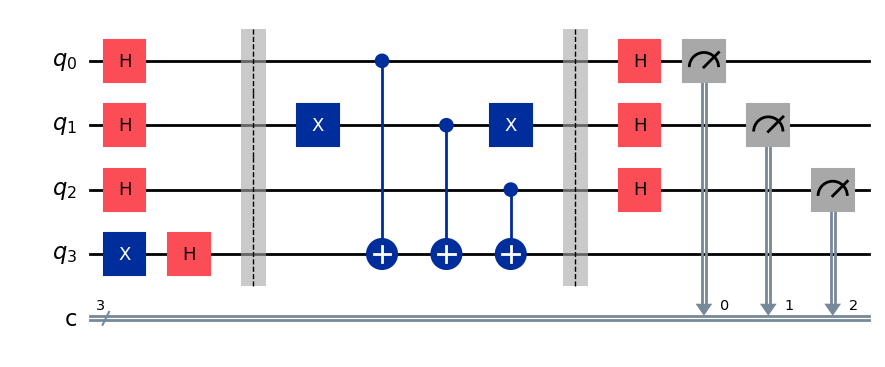

In [7]:
import numpy as np
from qiskit_aer import Aer
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
n = 3
dj_circuit = QuantumCircuit(n+1, n)
def dj_algorithm(case, n):
    dj_circuit = QuantumCircuit(n+1, n)
    # Setup
    dj_circuit.x(n)
    dj_circuit.h(n)
    for qubit in range(n):
        dj_circuit.h(qubit)
    dj_circuit.barrier()
    # Oracle
    if case == "balanced":
      b = np.random.randint(1,2**n)
      b_str = format(b, '0'+str(n)+'b')
      for qubit in range(len(b_str)):
        if b_str[qubit] == '1':
          dj_circuit.x(qubit)
      for qubit in range(n):
        dj_circuit.cx(qubit, n)
      for qubit in range(len(b_str)):
        if b_str[qubit] == '1':
          dj_circuit.x(qubit)
    if case == "constant":
      output = np.random.randint(2)
      if output == 1:
        dj_circuit.x(n)
    dj_circuit.barrier()
    # H-gates again and measure:
    for qubit in range(n):
        dj_circuit.h(qubit)
    for i in range(n):
        dj_circuit.measure(i, i)
    return dj_circuit
dj_circuit = dj_algorithm('balanced', n)
dj_circuit.draw('mpl')

In [8]:
simulator = Aer.get_backend('aer_simulator')
transpiled = transpile(dj_circuit, simulator)
result = simulator.run(transpiled).result()
counts = result.get_counts()
if '0'*n in counts and counts['0'*n] == 1024:
    print("Function is CONSTANT")
else:
    print("Function is BALANCED")

Function is BALANCED
